# Tracking Protocol

# Imports 

Required packages:

+ numpy 
+ matplotlib
+ expelliarmus
+ sklearn.metrics.pairwise

Please use ```pip install numpy matplotlib expelliarmus scikit-learn``` to proceed!

In [32]:
import numpy as np
from expelliarmus import Wizard
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
import matplotlib.pyplot as plt

## Loading data from a single sequence

In [4]:
# Data encoded in "dat" format
wizard = Wizard(encoding="dat")

# File path to the data file
fpath = "/data/tracking/PalmBackLaserOFF_01_cd.dat"
fpath = "/data/tracking/PalmBackLaserON_01_cd.dat"

# Set the file to be read
wizard.set_file(fpath)

# Read the data array of the events
events = wizard.read()

# Verification 
print(f"First event encoded as (t, x, y, p): {events[0]}")
print(f"Number of events: {len(events)}.")
print(f"Recording duration: {(events[-1]['t']-events[0]['t'])//int(1e6)} s.")

First event encoded as (t, x, y, p): (7840, 233, 253, 0)
Number of events: 23043034.
Recording duration: 43 s.


## Temporal binning of spot positions

In [ ]:
# Timestamps in microseconds
ts = events["t"].astype(np.int64)

# 100 ms = 100,000 µs
BIN_WIDTH_US = int(0.1 * 1e6)  

# Calculate the number of bins
t0 = ts.min()
t1 = ts.max()
duration_us = t1 - t0
num_bins = duration_us // BIN_WIDTH_US + 1

# Compute the bin index for each event
bin_indices = (ts - t0) // BIN_WIDTH_US

# Create a list of empty bins
bins = [[] for _ in range(num_bins)]

# Fill the bins
for evt, b in zip(events, bin_indices):
    bins[b].append(evt)

# Verification of binning (example output)
print(f"Number of bins: {num_bins}")
print(f"Bin 0 contains {len(bins[0])} events.")
print(f"Bin 1 contains {len(bins[1])} events.")

Number of bins: 437
Bin 0 contains 81284 events.
Bin 1 contains 61491 events.


## Aggregation

In [6]:
aggregated = []   # one row per 100-ms bin

for bin_events in bins:
    if len(bin_events) == 0:
        # No events → store zeros or NaN
        aggregated.append({
            "count": 0,
            "mean_x": np.nan,
            "mean_y": np.nan,
            "sum_p": 0
        })
        continue

    xs = np.array([e["x"] for e in bin_events])
    ys = np.array([e["y"] for e in bin_events])
    ps = np.array([e["p"] for e in bin_events])

    # Example: sum of polarities or intensities
    aggregated.append({
        "count": len(bin_events),
        "mean_x": xs.mean(),
        "mean_y": ys.mean(),
        "sum_p": ps.sum(),     
    })

# ~400 bins → ~400 data points
len(aggregated)   

437

## Computing trajectories and segments 

In [7]:
trajectory = np.array([
    [row["mean_x"], row["mean_y"]] for row in aggregated    # shape: (num_bins, 2)
])

# 10 × 100 ms = 1 second
WINDOW_SIZE = 10   
num_segments = len(trajectory) // WINDOW_SIZE

# shape = (num_segments, 10, 2)
segments = np.array([
    trajectory[i*WINDOW_SIZE : (i+1)*WINDOW_SIZE]
    for i in range(num_segments)
])  

# shape = (num_segments, 20)
flat_segments = segments.reshape(num_segments, -1)   

## Computing similarity
Quantify Variation Across Repeated Patterns

In [10]:
similarity_matrix = cosine_similarity(flat_segments, flat_segments)

## Labeling using KMeans
Quantify Variation Across Repeated Patterns

In [ ]:
k = 2   # Expect 2 repeating shapes, or choose automatically later
kmeans = KMeans(n_clusters=k, random_state=0)
labels = kmeans.fit_predict(flat_segments)

## Computing the PCA of the segments

In [ ]:
# Align segments using PCA for better comparison
aligned_segments = []
for seg in segments:
    # Center the segment
    centered = seg - seg.mean(axis=0)

    # PCA to align major axis for consistency
    pca = PCA(n_components=2)
    aligned = pca.fit_transform(centered)

    aligned_segments.append(aligned)

# Convert list to numpy array for further processing
aligned_segments = np.array(aligned_segments)

## Compute the silhouette score

In [21]:
mean_segment = aligned_segments.mean(axis=0)   # shape 10×2
std_segment = aligned_segments.std(axis=0)
silhouette = silhouette_score(flat_segments, labels)

# Verification 
print(f"Repeatability (silhouette score): {silhouette}")

Repeatability (silhouette score): 0.10032808343856871


## Computing the phase similarity

In [22]:
# Correlation-like measure for flattened segments
phase_sim = cosine_similarity(flat_segments)

## Amplitutde statistics 

In [23]:
# amplitude per cycle = mean distance traveled within each cycle
amplitude = []

for seg in aligned_segments:
    # With a shape (9,2)
    diffs = np.diff(seg, axis=0) 

    # Segment-to-segment steps                  
    dist = np.linalg.norm(diffs, axis=1) 

    # Total path length             
    amplitude.append(dist.sum())                      

amplitude = np.array(amplitude)
amp_mean = amplitude.mean()
amp_std  = amplitude.std()

## Computing drift

In [ ]:
# With a shape (num_cycles, 2)
centroids = aligned_segments.mean(axis=1)    

# Displacement relative to first cycle
centroid_drift = np.linalg.norm(
    centroids - centroids[0], axis=1)

## Normalization and phase computation

In [26]:
normalizer = Normalizer(norm='l2')
normed_segs = normalizer.fit_transform(flat_segments)

# Cosine similarity to cycle 0 = phase alignment measure
phase_similarity = normed_segs @ normed_segs[0]
phase_angle = np.arccos(np.clip(phase_similarity, -1, 1))

## Computing the temporal drift

In [ ]:
temporal_drift = []

for i in range(1, len(normed_segs)):
    # Similarity between consecutive 1-second cycles
    sim = normed_segs[i] @ normed_segs[i-1]
    temporal_drift.append(sim)
temporal_drift = np.array(temporal_drift)


In [29]:
# Exclude diagonal
mean_similarity = (similarity_matrix - np.eye(len(similarity_matrix))).mean()
std_similarity  = similarity_matrix.std()
min_similarity  = similarity_matrix.min()

## Verify the events variation summary

In [42]:
# Summary
variation_summary = {
    "amplitude_mean": amplitude.mean(),
    "amplitude_std": amplitude.std(),
    "phase_mean": phase_angle.mean(),
    "phase_std": phase_angle.std(),
    "spatial_drift_final": centroid_drift[-1],
    "temporal_drift_mean": temporal_drift.mean(),
    "temporal_drift_std": temporal_drift.std(),
    "cycle_similarity_mean": mean_similarity,
    "cycle_similarity_std": std_similarity,
    "cycle_similarity_min": min_similarity,
}
print("Variation Summary:")
for k, v in variation_summary.items():
    print(f"  {k}: {v}")

Variation Summary:
  amplitude_mean: 30.936271426333885
  amplitude_std: 7.002150757470393
  phase_mean: 0.011433422460967626
  phase_std: 0.0027192604721781068
  spatial_drift_final: 2.7714281517999473e-16
  temporal_drift_mean: 0.9999302903919888
  temporal_drift_std: 2.2299583026418787e-05
  cycle_similarity_mean: 0.9766661704854933
  cycle_similarity_std: 3.575340492445266e-05
  cycle_similarity_min: 0.9997663331562364


## Plotting: Amplitude per Cycle

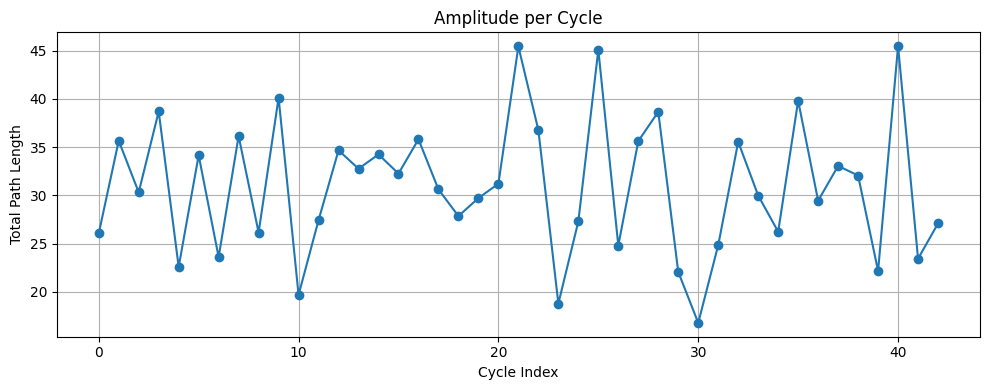

In [ ]:

plt.figure(figsize=(10, 4))
plt.plot(amplitude, marker='o')
plt.title("Amplitude per Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Total Path Length")
plt.grid(True)
plt.tight_layout()
plt.show()

## Plotting: Phase Shift per Cycle 

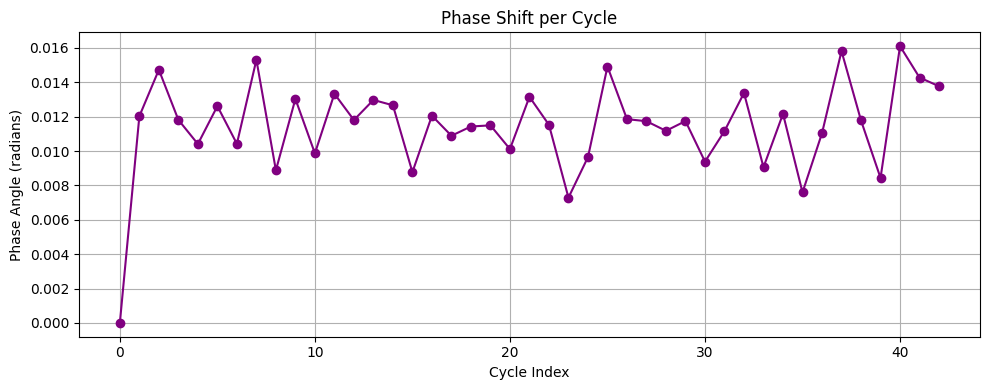

In [34]:
plt.figure(figsize=(10, 4))
plt.plot(phase_angle, marker='o', color='purple')
plt.title("Phase Shift per Cycle")
plt.xlabel("Cycle Index")
plt.ylabel("Phase Angle (radians)")
plt.grid(True)
plt.tight_layout()
plt.show()


## Plotting: Centroid Trajectory (XY Plane)

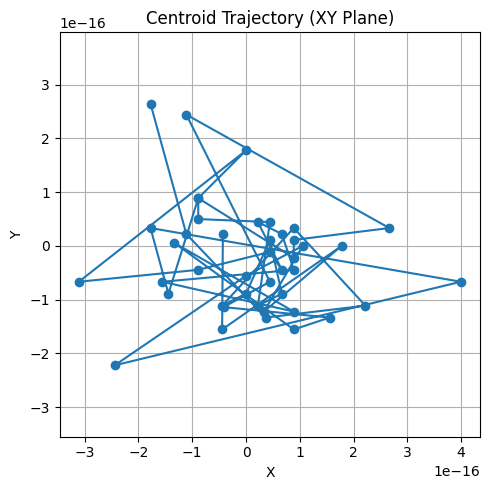

In [35]:
plt.figure(figsize=(5, 5))
plt.plot(centroids[:,0], centroids[:,1], marker='o')
plt.title("Centroid Trajectory (XY Plane)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

## Plotting: Temporal Drift (Consecutive Cycle Similarity)

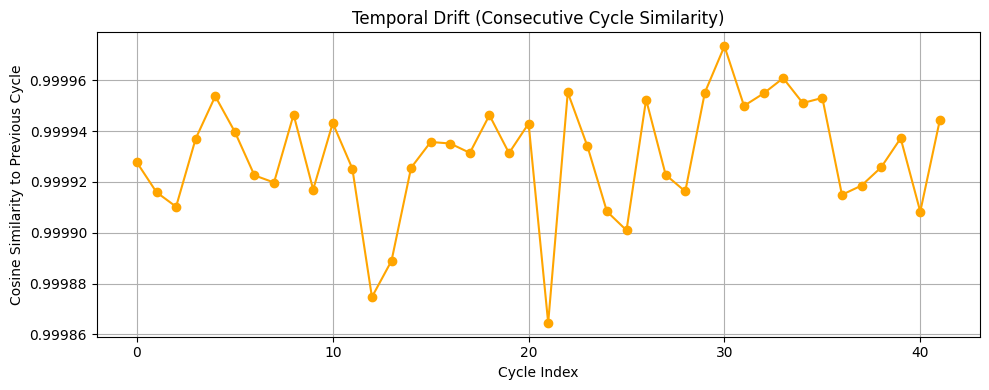

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(temporal_drift, marker='o', color='orange')
plt.title("Temporal Drift (Consecutive Cycle Similarity)")
plt.xlabel("Cycle Index")
plt.ylabel("Cosine Similarity to Previous Cycle")
plt.grid(True)
plt.tight_layout()
plt.show()

## Plotting: Cycle-to-Cycle Similarity Matrix

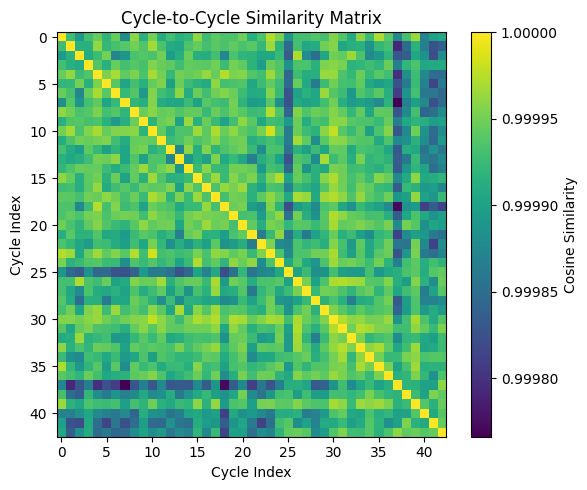

In [38]:
plt.figure(figsize=(6, 5))
plt.imshow(similarity_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.title("Cycle-to-Cycle Similarity Matrix")
plt.xlabel("Cycle Index")
plt.ylabel("Cycle Index")
plt.tight_layout()
plt.show()


## Plotting: Spatial Drift of Segment Centroids

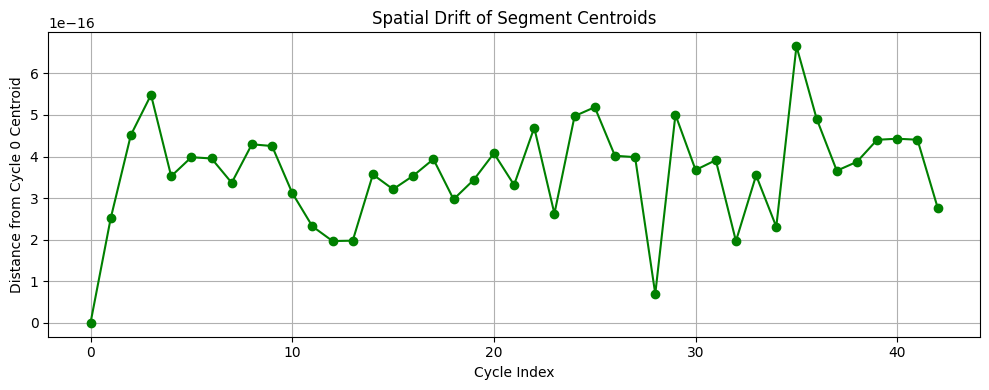

In [39]:
phase_deg = np.degrees(phase_angle)
plt.figure(figsize=(10, 4))
plt.plot(centroid_drift, marker='o', color='green')
plt.title("Spatial Drift of Segment Centroids")
plt.xlabel("Cycle Index")
plt.ylabel("Distance from Cycle 0 Centroid")
plt.grid(True)
plt.tight_layout()
plt.show()


## Plotting Motion Estimation

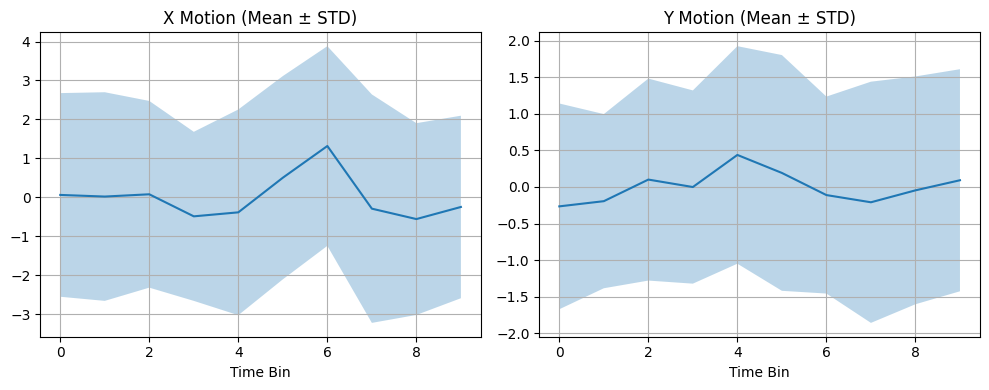

In [40]:
mean_seg = aligned_segments.mean(axis=0)      # 10×2
std_seg  = aligned_segments.std(axis=0)       # 10×2
t = np.arange(10)

plt.figure(figsize=(10, 4))

# X trajectory
plt.subplot(1,2,1)
plt.plot(t, mean_seg[:,0], label="mean X")
plt.fill_between(t, mean_seg[:,0]-std_seg[:,0], mean_seg[:,0]+std_seg[:,0], alpha=0.3)
plt.title("X Motion (Mean ± STD)")
plt.xlabel("Time Bin")
plt.grid(True)

# Y trajectory
plt.subplot(1,2,2)
plt.plot(t, mean_seg[:,1], label="mean Y")
plt.fill_between(t, mean_seg[:,1]-std_seg[:,1], mean_seg[:,1]+std_seg[:,1], alpha=0.3)
plt.title("Y Motion (Mean ± STD)")
plt.xlabel("Time Bin")
plt.grid(True)

plt.tight_layout()
plt.show()
